In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.signal import hilbert

In [3]:
id = 'sub-010003'
condition = 'EO' 

preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed'
path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

raw = mne.io.read_raw_fif(path, preload=True)
raw.load_data()
raw = raw.copy().pick("eeg")

Opening raw data file D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010003\sub-010003_EO_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Range : 187348 ... 1347356 =     74.939 ...   538.942 secs
Ready.
Reading 0 ... 1160008  =      0.000 ...   464.003 secs...


In [4]:
epoch_duration = 2.0

# Create fixed-length events
events = mne.make_fixed_length_events(raw, id=1, duration=epoch_duration)
    
# Create epochs
epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
                        baseline=None, preload=True, reject_by_annotation=False)

Not setting metadata
232 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 232 events and 5001 original time points ...
0 bad epochs dropped


In [10]:

data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
sfreq = epochs.info['sfreq']

# --- Hilbert Transform ---
analytic_signal = hilbert(data, axis=-1)
phase = np.angle(analytic_signal)
# phase = np.mean(phase, axis=0)

In [11]:
n_channels = phase.shape[0]
psi_matrix = np.zeros((n_channels, n_channels))

# Compute n:m phase-phase coupling for each channel pair
for i in range(n_channels):
    for j in range(n_channels):
        phase_diff = phase[j] - phase[i]
        # Compute PSI for the current m
        psi = np.abs(np.mean(np.exp(1j * phase_diff)))
        psi_matrix[i, j] = psi

    psi_matrix = np.array(psi_matrix)

print(psi_matrix)

KeyboardInterrupt: 

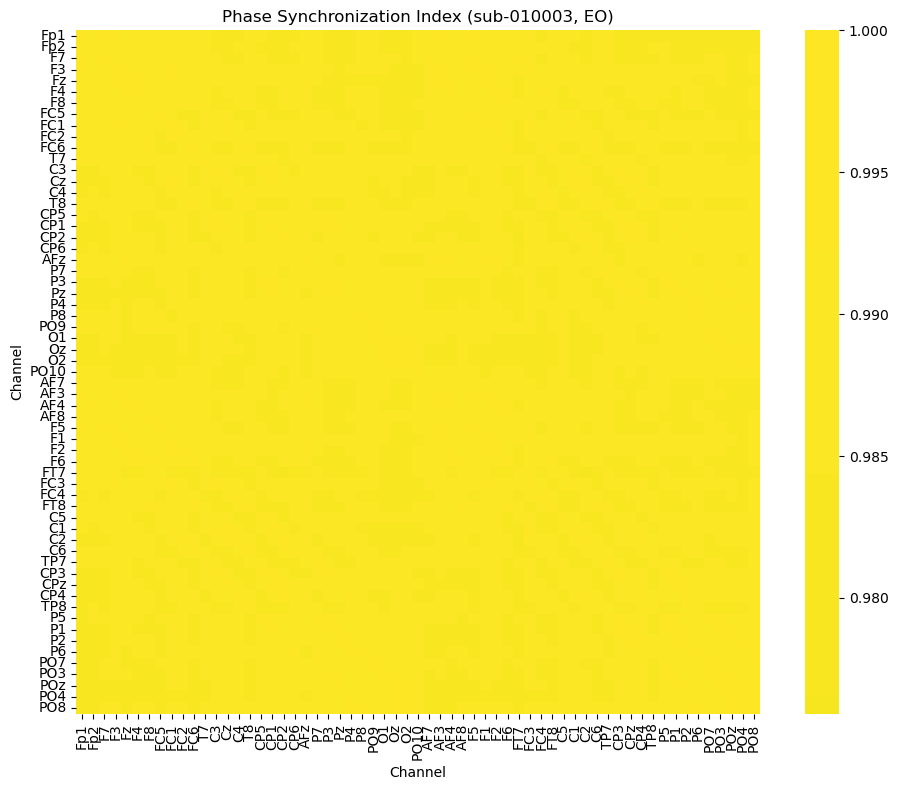

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(psi_matrix, xticklabels=epochs.ch_names, yticklabels=epochs.ch_names,
        cmap='viridis', center=0, annot=False, fmt=".2f", square=True)
plt.title(f'Phase Synchronization Index ({id}, {condition})')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()


In [ ]:
def compute_phase(x):
    """ヒルベルト変換で瞬時位相を計算"""
    from scipy.signal import hilbert
    return np.angle(hilbert(x))

def PSI(x, y, N=100):
    """Phase Synchronization Index"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta_phase = phase_x - phase_y
    psi_vals = []
    for i in range(0, len(delta_phase)-N):
        psi_vals.append(np.abs(np.mean(np.exp(1j*delta_phase[i:i+N]))))
    return np.array(psi_vals)

def Imaginary_Coh(x, y):
    """Imaginary Coherence"""
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    csd = X * np.conj(Y)
    imag_coh = np.imag(np.mean(csd)) / np.sqrt(np.mean(np.abs(X)**2) * np.mean(np.abs(Y)**2))
    return np.abs(imag_coh)

def PLI(x, y):
    """Phase Lag Index"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta_phase = phase_x - phase_y
    return np.abs(np.mean(np.sign(np.sin(delta_phase))))

def wPLI(x, y):
    """Weighted Phase Lag Index"""
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    imag_part = np.imag(X * np.conj(Y))
    return np.abs(np.sum(np.abs(imag_part) * np.sign(imag_part))) / np.sum(np.abs(imag_part))

def dPSI(x, y, fs=250):
    """Differential PSI（位相遅れの変化量を評価）"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta = np.unwrap(phase_x - phase_y)
    d_delta = np.diff(delta)
    return np.mean(np.abs(d_delta))

In [ ]:
PSI(x, y, N=100)

In [15]:
from scipy.signal import welch
import numpy as np

def compute_psd_multichannel(raw, nperseg=None):
    """
    raw : MNE Raw オブジェクト
    nperseg : Welch 法の窓長（サンプル数）
    """
    data = raw.get_data()  # shape = (n_channels, n_samples)
    fs = raw.info["sfreq"]
    n_channels = data.shape[0]

    # デフォルトの窓長 = 2秒
    if nperseg is None:
        nperseg = int(fs * 2)

    # PSDを保存するリスト
    psd_list = []
    freqs = None

    for ch in range(n_channels):
        f, Pxx = welch(data[ch], fs=fs, nperseg=nperseg)
        if freqs is None:
            freqs = f
        psd_list.append(Pxx)

    psd_array = np.array(psd_list)  # shape = (n_channels, n_freqs)

    return freqs, psd_array


In [16]:
import matplotlib.pyplot as plt

def plot_psd_all_channels(freqs, psd_array, fmax=60):
    plt.figure(figsize=(10, 6))
    for ch in range(psd_array.shape[0]):
        plt.plot(freqs, psd_array[ch], alpha=0.3)

    plt.xlim(0, fmax)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title("PSD of All Channels (Welch)")
    plt.grid(True)
    plt.show()


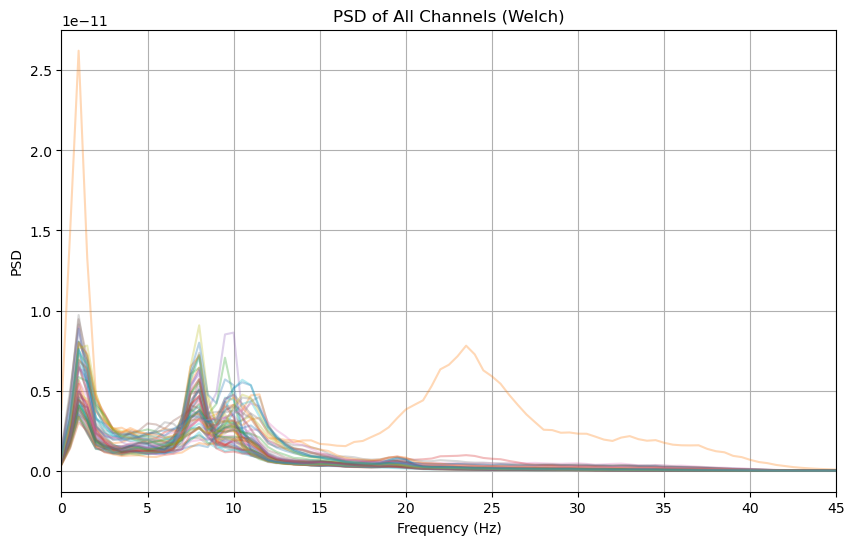

In [18]:
freqs, psd_array = compute_psd_multichannel(raw)
plot_psd_all_channels(freqs, psd_array, fmax=45)

In [19]:
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}


In [20]:
from scipy.signal import welch
import numpy as np

def compute_band_power(raw, bands, nperseg=None):
    """
    raw: MNE Raw object
    bands: dict → 各バンドの周波数帯
    """

    data = raw.get_data()   # (n_channels, n_samples)
    fs = raw.info['sfreq']

    if nperseg is None:
        nperseg = int(fs * 2)  # 2秒窓

    # PSD 計算（チャンネル×周波数）
    freqs, psd = welch(
        data,
        fs=fs,
        nperseg=nperseg,
        axis=1
    )

    band_power = {}

    for band_name, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_power[band_name] = np.mean(psd[:, idx], axis=1)  # (n_channels)

    return freqs, psd, band_power


In [21]:
import mne
import matplotlib.pyplot as plt

def plot_bandpower_topomap(raw, band_power, band_name):
    """
    raw: MNE Raw object
    band_power: band_power[band_name] の 1次元配列（n_channels）
    """

    mne.viz.plot_topomap(
        band_power,
        raw.info,
        cmap="viridis",
        contours=0,
        sphere=0.1
    )

    plt.title(f"{band_name} band power")
    plt.show()


In [22]:
def plot_all_band_topomaps(raw, band_power):
    for band in band_power.keys():
        plot_bandpower_topomap(raw, band_power[band], band)


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bandpower_bar(band_power):
    """
    band_power: compute_band_power() で得られる dict
                {band_name: (n_channels,) }
    """

    band_names = list(band_power.keys())
    mean_values = [np.mean(band_power[b]) for b in band_names]

    plt.figure(figsize=(10, 5))
    plt.bar(band_names, mean_values)
    plt.ylabel("Mean Power (μV²/Hz)")
    plt.title("Band Power (Averaged across Channels)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


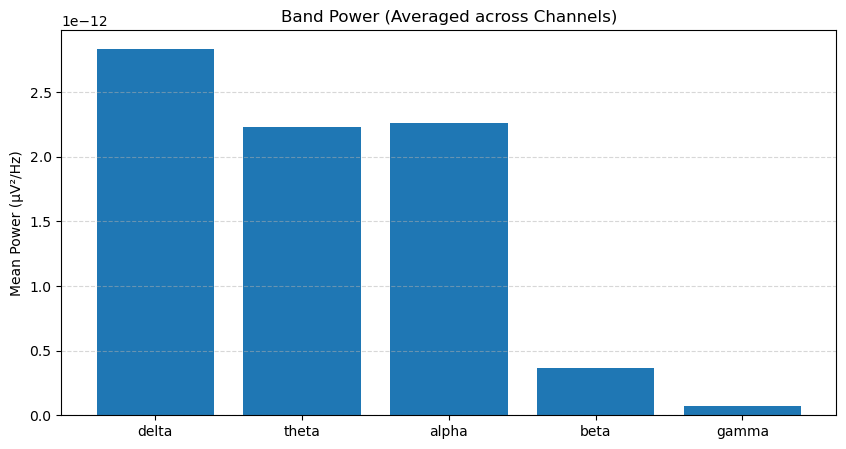

In [25]:
plot_bandpower_bar(band_power)

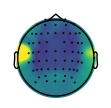

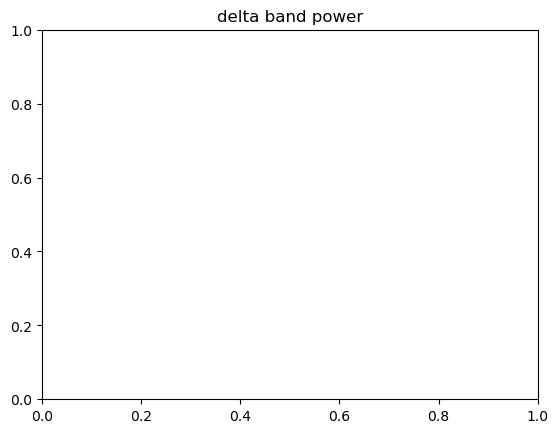

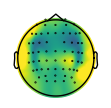

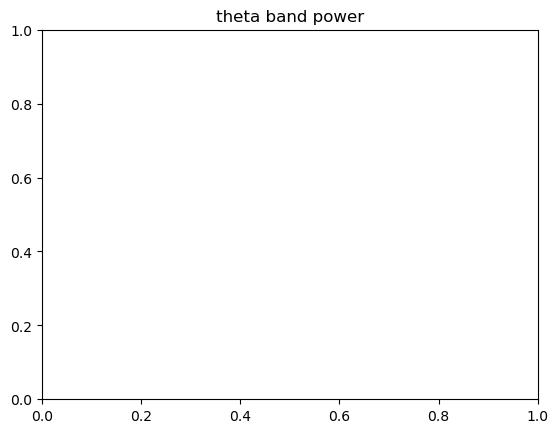

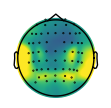

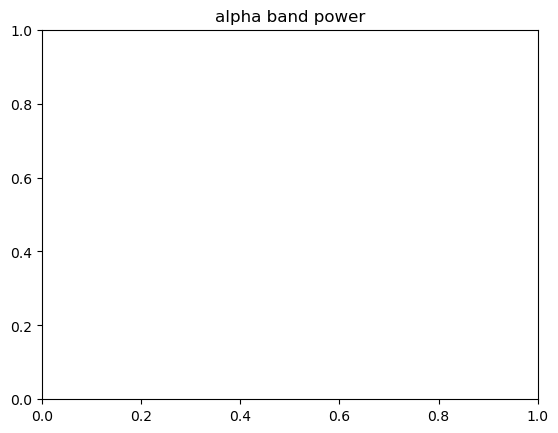

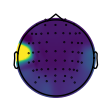

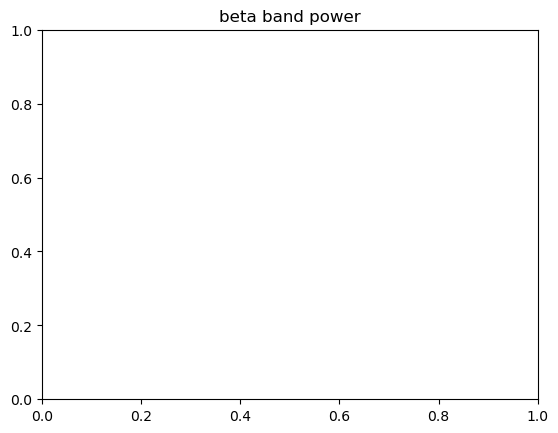

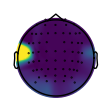

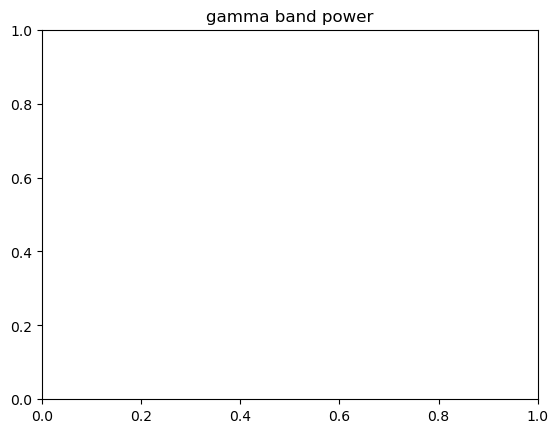

In [23]:
# Band power 計算
freqs, psd, band_power = compute_band_power(raw, bands)

# 各バンドのパワーをトポマップで表示
plot_all_band_topomaps(raw, band_power)


In [4]:
import mne
import numpy as np
import pandas as pd
import glob
import os
from scripts.eeg.connectivity import get_subject_ids, get_subject_metadata

# ▼ 周波数帯域の設定
FREQ_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45)
}

# ▼ 入出力
preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed\\'
OUTPUT_CSV = "./bandpower_61ch_mean.csv"
metadata_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\metadata\\Participants_MPILMBB_LEMON.csv'

rows = []

# ▼ データ読み込みループ

subject_ids = get_subject_ids(preprocess_path)    

for id in subject_ids:
    for condition in ['EO', 'EC']:
        print(f"==={id}_{condition}===")
        # Define the paths to the raw EEG files
        path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

        # Load the raw data
        if not os.path.exists(path):
            print(f"Raw EEG file for condition {condition} does not exist: {path}")
            continue
        # Load the raw data   
        raw = mne.io.read_raw_fif(path, preload=True)
        if not raw.preload:
            raw.load_data()
        
        meta_info = get_subject_metadata(id, metadata_path)
        sex = meta_info["sex"]
        group = meta_info["group"]

        print("processing:", id)

        raw.filter(1, 45)

        # ▼ PSD（Power Spectral Density）
        psd, freqs = mne.time_frequency.psd_welch(raw, fmin=1, fmax=45, n_fft=1024)

        # ▼ 61ch 平均（PSD の shape: ch × freq）
        psd_mean_ch = psd.mean(axis=0)

        # ▼ バンドパワー計算
        band_vals = {}
        for band, (fmin, fmax) in FREQ_BANDS.items():
            idx = np.logical_and(freqs >= fmin, freqs < fmax)
            band_vals[band] = psd_mean_ch[idx].mean()

        # ▼ 1行分追加
        row = {
            "subject_id": id,
            "sex": sex,
            "group": group,
            "condition": condition
        }
        row.update(band_vals)
        rows.append(row)

        # ▼ 保存
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)

===sub-010002_EO===
processing: sub-010002


C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_49916\2108701695.py:49: RuntimeWarning: filter_length (8251) is longer than the signal (5001), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(1, 45)


AttributeError: No mne.time_frequency attribute psd_welch

In [ ]:
# sliding_psi.py
import numpy as np
from scipy.signal import hilbert
from tqdm import trange
import mne

mne.set_log_level('ERROR')  # quiet mne messages

# --- utility functions ----------------------------------------------------

BAND_DEFS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

def center_freq(band):
    a, b = band
    return 0.5 * (a + b)

def window_length_from_cycles(freq_hz, cycles=6, min_sec=0.5, max_sec=10.0):
    """Return window length in seconds given center frequency and cycles."""
    if freq_hz <= 0:
        return max(min_sec, 1.0)
    wl = cycles / freq_hz
    wl = max(wl, min_sec)
    wl = min(wl, max_sec)
    return wl

def fir_filter_data(data, sfreq, l_freq, h_freq):
    """
    data: ndarray (n_channels, n_times)
    returns filtered data (same shape) using mne.filter.filter_data (FIR zero-phase)
    """
    # mne.filter.filter_data expects shape (n_channels, n_times)
    filtered = mne.filter.filter_data(
        data.copy(), sfreq=sfreq, l_freq=l_freq, h_freq=h_freq,
        method='fir', phase='zero', verbose=False
    )
    return filtered

# --- synchronization measures ---------------------------------------------

def compute_phase(data_win):
    """analytic signal phase for data_win shape (n_channels, n_times_window)."""
    return np.angle(hilbert(data_win, axis=1))

def psi_between_phase(phase_i, phase_j):
    """phase_i, phase_j: vectors (n_times,)
       return PSI (1:1)"""
    phase_diff = phase_j - phase_i
    return np.abs(np.mean(np.exp(1j * phase_diff)))

def pli_between_phase(phase_i, phase_j):
    """PLI = |mean(sign(sin(delta_phase)))| (equivalently sign of imaginary part)"""
    phase_diff = phase_j - phase_i
    return np.abs(np.mean(np.sign(np.sin(phase_diff))))

def wpli_between_analytic(x, y):
    """wPLI on analytic signals x,y (shape n_times). Uses sample-wise imag(X * conj(Y))."""
    im = np.imag(x * np.conj(y))
    denom = np.mean(np.abs(im))
    if denom == 0:
        return 0.0
    num = np.abs(np.mean(np.sign(im) * np.abs(im)))
    return num / denom

def imag_coherence_between_analytic(x, y):
    """Imaginary coherence (normalized imaginary part of cross-spectrum)."""
    # sample-wise cross-spectral term
    cross = x * np.conj(y)
    im_mean = np.abs(np.mean(np.imag(cross)))
    pxx = np.mean(np.abs(x) ** 2)
    pyy = np.mean(np.abs(y) ** 2)
    denom = np.sqrt(pxx * pyy)
    if denom == 0:
        return 0.0
    return im_mean / denom

# --- main pipeline -------------------------------------------------------

def compute_dynamic_measures(
    data,               # (n_channels, n_times)
    sfreq,
    band_list = ["delta", "theta", "alpha", "beta"],
    cycles = 6,
    overlap = 0.5,
    m_max_extra = 3,    # extra margin when estimating m_max
    min_win_sec = 0.5,
    max_win_sec = 10.0,
    verbose = True
):
    """
    Compute dynamic PSI/PLI/wPLI/imag_coh for same-band and cross-band (n:m).
    Returns a dict with keys:
      - 'per_pair': dict[(b1,b2)] -> dict with:
            'windows' : list of window center times (sec)
            'psi_windows': ndarray (n_windows, n_ch, n_ch)
            'psi_mean'   : ndarray (n_ch, n_ch)   # average across windows
            similarly for 'pli', 'wpli', 'imcoh'
            if b1 != b2: includes 'best_m_windows' list and 'best_m_mean'
    """

    n_ch, n_times = data.shape
    results = {"per_pair": {}}

    # Precompute center freqs and window lengths (use lower-band when cross?)
    band_bounds = {b: BAND_DEFS[b] for b in band_list}
    band_fc = {b: center_freq(band_bounds[b]) for b in band_list}
    band_win = {b: window_length_from_cycles(band_fc[b], cycles, min_win_sec, max_win_sec)
                for b in band_list}

    if verbose:
        print("Bands:", band_list)
        for b in band_list:
            print(f"  {b}: {band_bounds[b]}, center {band_fc[b]:.2f} Hz, win {band_win[b]:.2f}s")

    # For each band, pre-filter the entire recording (FIR zero-phase)
    filtered_data = {}
    for b in band_list:
        l, h = band_bounds[b]
        filtered_data[b] = fir_filter_data(data, sfreq, l, h)

    # For each pair:
    for idx1, b1 in enumerate(band_list):
        for idx2, b2 in enumerate(band_list[idx1:]):
            # ensure ordered pair (b1,b2) where idx2 >= idx1
            # we'll store both (b1,b2) and (b2,b1) if needed later
            if idx1 == idx2:
                pair_key = (b1, b1)
            else:
                pair_key = (b1, b2)

            if verbose:
                print(f"\nProcessing pair {pair_key}")

            data1 = filtered_data[b1]  # (n_ch, n_times)
            data2 = filtered_data[b2]

            # choose window length: if same-band, use that band's win;
            # if cross-band, use the longer of the two (to capture slow cycles)
            if b1 == b2:
                win_sec = band_win[b1]
            else:
                # use max of both windows to ensure adequate cycles of the lower band
                win_sec = max(band_win[b1], band_win[b2])

            step_sec = win_sec * (1.0 - overlap)
            n_win = int(np.floor((n_times / sfreq - win_sec) / step_sec) + 1)
            if n_win < 1:
                # fallback: single window
                n_win = 1
                step_sec = 0
            if verbose:
                print(f"  window {win_sec:.3f}s step {step_sec:.3f}s -> n_win {n_win}")

            # prepare containers
            psi_windows = np.zeros((n_win, n_ch, n_ch))
            pli_windows = np.zeros((n_win, n_ch, n_ch))
            wpli_windows = np.zeros((n_win, n_ch, n_ch))
            imcoh_windows = np.zeros((n_win, n_ch, n_ch))
            best_m_windows = []  # per-window best m for cross-band; for same-band keep 1

            # precompute time indices for windows
            win_samples = int(round(win_sec * sfreq))
            step_samples = int(round(step_sec * sfreq)) if step_sec > 0 else 0
            win_centers = []

            for w in trange(n_win, desc=f"{b1}-{b2}", disable=not verbose):
                start_samp = w * step_samples
                end_samp = start_samp + win_samples
                if end_samp > n_times:
                    # pad or clip: clip here
                    start_samp = max(0, n_times - win_samples)
                    end_samp = n_times
                win_centers.append((start_samp + end_samp) / 2.0 / sfreq)

                x1 = data1[:, start_samp:end_samp]  # (n_ch, win_samples)
                x2 = data2[:, start_samp:end_samp]

                # analytic signals
                a1 = hilbert(x1, axis=1)   # complex
                a2 = hilbert(x2, axis=1)

                # phases (n_ch, win_samples)
                ph1 = np.angle(a1)
                ph2 = np.angle(a2)

                # If same band, simple 1:1
                if b1 == b2:
                    for i in range(n_ch):
                        for j in range(n_ch):
                            psi_windows[w, i, j] = psi_between_phase(ph1[i], ph2[j])
                            #pli_windows[w, i, j] = pli_between_phase(ph1[i], ph2[j])
                            #wpli_windows[w, i, j] = wpli_between_analytic(a1[i], a2[j])
                            #imcoh_windows[w, i, j] = imag_coherence_between_analytic(a1[i], a2[j])
                    best_m_windows.append(1)
                else:
                    # cross-band: sweep m for n=1
                    f1c = band_fc[b1]
                    f2c = band_fc[b2]
                    # rough m_max: ceil(f2c/f1c) + margin
                    if f1c == 0:
                        m_max = 1
                    else:
                        m_max = int(np.ceil(f2c / f1c)) + m_max_extra
                        if m_max < 1:
                            m_max = 1
                    best_m_for_window = np.ones((n_ch, n_ch), dtype=int) * 1
                    best_psi_for_window = np.zeros((n_ch, n_ch))

                    # For efficiency: compute phase arrays once per channel pair inside loops
                    for i in range(n_ch):
                        for j in range(n_ch):
                            # sweep m
                            best_psi = -1.0
                            best_m = 1
                            for m in range(1, m_max + 1):
                                phase_diff = 1 * ph2[j] - m * ph1[i]
                                psi_val = np.abs(np.mean(np.exp(1j * phase_diff)))
                                if psi_val > best_psi:
                                    best_psi = psi_val
                                    best_m = m
                            psi_windows[w, i, j] = best_psi
                            best_m_for_window[i, j] = best_m
                            # compute other metrics using analytic signals at 1:1 alignment (not n:m):
                            # For connectivity metrics like wPLI/PLI/imcoh we normally compute narrowband between
                            # the same filtered signals, so we compute them here (they reflect band-band interactions)
                            #pli_windows[w, i, j] = pli_between_phase(ph1[i], ph2[j])
                            #wpli_windows[w, i, j] = wpli_between_analytic(a1[i], a2[j])
                            #imcoh_windows[w, i, j] = imag_coherence_between_analytic(a1[i], a2[j])

                    # store best_m matrix averaged (or keep full matrix)
                    # here we store the per-window average best m (rounded) for convenience
                    best_m_windows.append(best_m_for_window)

            # average across windows
            psi_mean = np.mean(psi_windows, axis=0)
            #pli_mean = np.mean(pli_windows, axis=0)
            #wpli_mean = np.mean(wpli_windows, axis=0)
            #imcoh_mean = np.mean(imcoh_windows, axis=0)

            results["per_pair"][pair_key] = {
                "windows": win_centers,
                "psi_windows": psi_windows,
                "psi_mean": psi_mean,
                # "pli_windows": pli_windows,
                # "pli_mean": pli_mean,
                # "wpli_windows": wpli_windows,
                # "wpli_mean": wpli_mean,
                # "imcoh_windows": imcoh_windows,
                # "imcoh_mean": imcoh_mean,
                # "best_m_windows": best_m_windows,
            }

            # if pair was not symmetrical (b1 != b2), also store reversed key for convenience
            if b1 != b2:
                results["per_pair"][(b2, b1)] = results["per_pair"][pair_key]

    return results

# --- Example usage -------------------------------------------------------

if __name__ == "__main__":
    # quick synthetic test
    
    # --------------------------------------------------------
    # ② Raw を読み込む
    # --------------------------------------------------------
    DATA_DIR = "D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed"
    groupA_paths = [f"{DATA_DIR}\sub-010003\sub-010003_EC_eeg.fif"]#, f"{DATA_DIR}\sub-010005\sub-010005_EC_eeg.fif"]  # young
    groupB_paths = [f"{DATA_DIR}\sub-010002\sub-010002_EC_eeg.fif"]#, f"{DATA_DIR}\sub-010004\sub-010004_EC_eeg.fif"]  # old

    for path in groupA_paths + groupB_paths:
        print("Loading:", path)
    
        # Raw データ読み込み
        raw = mne.io.read_raw_fif("your_eeg_raw.fif", preload=True)
        raw.pick_types(eeg=True)
        sfreq = raw.info["sfreq"]

        # データ: shape (n_channels, n_times)
        data = raw.get_data()

        # --------------------------------------------------------
        # ③ バンドごとに dynamic PSI を計算
        # --------------------------------------------------------
        band_list = ["alpha"]
        results = compute_dynamic_measures(
        data=data,
        sfreq=sfreq,
        band_list=band_list,
        cycles=6,
        overlap=0.5,
        verbose=True
        )
        # --------------------------------------------------------

        
        if pair_key not in data_dict:
            data_dict[pair_key] = {}
        data_dict[pair_key][subj_id] = per_pair_data["psi_mean"]


In [ ]:
import os
import pickle
import numpy as np
import mne
from mne.stats import permutation_cluster_test
from tqdm import tqdm

def load_per_pair_results(pair_result_path):
    """
    指定ディレクトリ内の per_pair pickle ファイルを全て読み込む
    Returns:
        data_dict: {pair_key: {subject_id: psi_mean}}
    """
    data_dict = {}
    for fname in os.listdir(pair_result_path):
        if fname.endswith(".pkl") and fname.startswith("psi_"):
            filepath = os.path.join(pair_result_path, fname)
            with open(filepath, "rb") as f:
                per_pair_data = pickle.load(f)
            
            # ファイル名からチャネルと被験者情報を取得
            _, ch1, ch2, subj_id, condition = fname.replace(".pkl","").split("_")
            pair_key = (ch1, ch2)
            
            if pair_key not in data_dict:
                data_dict[pair_key] = {}
            data_dict[pair_key][subj_id] = per_pair_data["psi_mean"]
    return data_dict

def generate_surrogates(data_array, n_surr=1000, random_state=None):
    """
    位相ランダム化によるサロゲートデータ生成
    Inputs:
        data_array: shape (n_subjects,)
    Returns:
        surrogate_means: shape (n_surr,)
    """
    rng = np.random.default_rng(random_state)
    n = len(data_array)
    surrogate_means = []
    for _ in range(n_surr):
        permuted = rng.permutation(data_array)
        surrogate_means.append(np.mean(permuted))
    return np.array(surrogate_means)

def compute_p_values(data_dict, group_labels, n_surr=1000):
    """
    各チャネルペアについて PSI_mean の群間比較とサロゲート法による有意性評価
    Inputs:
        data_dict: {pair_key: {subject_id: psi_mean}}
        group_labels: {subject_id: 'young' or 'old'}
    Returns:
        p_values_dict: {pair_key: p_value}
    """
    p_values_dict = {}
    for pair_key, subj_data in data_dict.items():
        # 群別にデータを抽出
        young_data = np.array([v for sid,v in subj_data.items() if group_labels[sid]=='young'])
        old_data = np.array([v for sid,v in subj_data.items() if group_labels[sid]=='old'])
        
        # 群間差の平均
        observed_diff = np.mean(old_data) - np.mean(young_data)
        
        # サロゲートによる p 値計算
        pooled = np.concatenate([young_data, old_data])
        surrogate_diffs = []
        rng = np.random.default_rng()
        for _ in range(n_surr):
            rng.shuffle(pooled)
            s_young = pooled[:len(young_data)]
            s_old = pooled[len(young_data):]
            surrogate_diffs.append(np.mean(s_old) - np.mean(s_young))
        surrogate_diffs = np.array(surrogate_diffs)
        
        # 両側検定
        p_value = np.mean(np.abs(surrogate_diffs) >= np.abs(observed_diff))
        p_values_dict[pair_key] = p_value
    return p_values_dict

def cluster_based_test(data_dict, group_labels, threshold=None, n_permutations=1000):
    """
    MNE の spatiotemporal cluster test を用いた群間比較
    入力データは PSI_mean で各チャネルペアごと
    """
    # データ行列化: n_subjects x n_features (チャネルペア)
    pair_keys = sorted(data_dict.keys())
    subj_ids = list(next(iter(data_dict.values())).keys())
    data_matrix = np.array([[data_dict[pair][sid] for pair in pair_keys] for sid in subj_ids])
    
    # 群ラベルに応じて分割
    group_vector = np.array([group_labels[sid] for sid in subj_ids])
    X1 = data_matrix[group_vector=='young']
    X2 = data_matrix[group_vector=='old']
    
    # permutation cluster test
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test([X1, X2],
                                                                     n_permutations=n_permutations,
                                                                     threshold=threshold,
                                                                     tail=0,  # 両側
                                                                     out_type='mask',
                                                                     adjacency=None)  # チャネル間 adjacency は今回は None
    return T_obs, clusters, cluster_p_values

import pandas as pd

# ===== メタデータ CSV のパス =====
metadata_path = "./metadata.csv"

# ===== 例: すでに定義済みの関数 =====
def get_subject_info(subject_id, metadata_path):
    meta_df = pd.read_csv(metadata_path)
    meta_df.columns = ["subject_id", "gender_code", "age_range"]

    row = meta_df[meta_df["subject_id"] == subject_id]
    if row.empty:
        return {"sex": "unknown", "group": "unknown"}

    gender_code = int(row.iloc[0]["gender_code"])
    if gender_code == 1:
        sex = "female"
    elif gender_code == 2:
        sex = "male"
    else:
        sex = "unknown"

    age_range = str(row.iloc[0]["age_range"])
    if any(x in age_range for x in ["20", "25", "30"]):
        group = "young"
    elif any(x in age_range for x in ["65", "70", "75", "80"]):
        group = "old"
    else:
        group = "unknown"

    return {"sex": sex, "group": group}

# ===== 実行パイプライン =====
args = type('Args', (), {})()  # ダミーオブジェクト
args.pair_result_path = "./pair_results"

# ===== group_labels 作成 =====
meta_df = pd.read_csv(metadata_path)
subject_ids = meta_df["subject_id"].tolist()

group_labels = {}
for sid in subject_ids:
    info = get_subject_info(sid, metadata_path)
    group_labels[sid] = info["group"]

# 確認
#print(group_labels)

# 1. 保存済み PSI_mean データ読み込み
#data_dict = load_per_pair_results(args.pair_result_path)

# PSI の平均値（例: 0〜1 の値）を疑似生成
np.random.seed(42)

# 若年群 10 名・高齢群 10 名の疑似 PSI 値
young_dummy = np.random.uniform(0.4, 0.6, 10)
old_dummy   = np.random.uniform(0.5, 0.9, 10)

data_dict = {
    "young": young_dummy,
    "old": old_dummy
}

# 2. サロゲート法による有意性評価
p_values_dict = compute_p_values(data_dict, group_labels, n_surr=1000)

# CSV 出力
import csv
with open("psi_mean_group_comparison.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["ch1","ch2","p_value"])
    for pair_key, pval in p_values_dict.items():
        writer.writerow([pair_key[0], pair_key[1], pval])

# 3. クラスターベース統計（簡易版）
T_obs, clusters, cluster_p_values = cluster_based_test(data_dict, group_labels)

print("Permutation cluster test done")
print("Cluster p-values:", cluster_p_values)

significant_cluster = cluster_p_values < 0.05
T_obs_plot = T_obs.copy()
T_obs_plot[~significant_cluster] = 0  # 有意でない部分は 0 に

mne.viz.plot_topomap(T_obs_plot[:, time_index], pos=layout.pos, show=True)


In [9]:
import numpy as np
import mne
from mne.channels import make_standard_montage
from mne.stats import permutation_cluster_test
import matplotlib.pyplot as plt

%matplotlib inline  # ← Jupyter なら追加

# -----------------------------
# 疑似データ
# -----------------------------
n_subjects = 20
n_channels = 61
np.random.seed(42)

group_labels = np.array([0]*10 + [1]*10)

young_data = np.random.uniform(0.2, 0.4, (10, n_channels))
old_data   = np.random.uniform(0.4, 0.7, (10, n_channels))

X = [young_data, old_data]

# -----------------------------
# クラスターベース permutation test
# -----------------------------
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    X,
    n_permutations=500,
    out_type="mask",
)

# -----------------------------
# 頭皮位置
# -----------------------------
montage = make_standard_montage("standard_1020")
info = mne.create_info(ch_names=montage.ch_names[:n_channels],
                       sfreq=1000, ch_types="eeg")
info.set_montage(montage)
pos = np.array([info['chs'][i]['loc'][:2] for i in range(n_channels)])

# -----------------------------
# 有意クラスタマスク作成
# -----------------------------
significant_mask = np.zeros(n_channels, dtype=bool)

for cluster, p in zip(clusters, cluster_p_values):
    if p < 0.05:
        cluster_mask = np.array(cluster, dtype=bool)
        significant_mask = np.logical_or(significant_mask, cluster_mask)

# -----------------------------
# topomap 用データ
# -----------------------------
T_plot = T_obs.copy()
T_plot[~significant_mask] = 0

# -----------------------------
# トポマップ表示
# -----------------------------
plt.figure(figsize=(6, 4))
mne.viz.plot_topomap(T_plot, pos, cmap="RdBu_r", show=True)
plt.title("Significant PSI Clusters (dummy data)")



UsageError: unrecognized arguments: # ← Jupyter なら追加


In [ ]:
import numpy as np
import mne
from mne.connectivity import spectral_connectivity
from mne.stats import permutation_cluster_test
from mne.viz import plot_connectivity_circle
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1) EEG frequency bands
# ------------------------------------------------------------
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}


# ------------------------------------------------------------
# 2) Compute PSI / PLI / wPLI using Hilbert
# ------------------------------------------------------------
def compute_connectivity_measures(raw, fmin, fmax):
    """Compute PSI / PLI / wPLI using MNE Hilbert."""
    raw_f = raw.copy().filter(fmin, fmax, fir_design="firwin")
    raw_f.apply_hilbert(envelope=False)

    data = raw_f.get_data()
    sfreq = raw.info["sfreq"]

    con = spectral_connectivity(
        data[np.newaxis, :, :],
        method=["pli", "wpli", "imcoh"],
        mode="hilbert",
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        tmin=0,
        tmax=None,
    )

    pli = con.get_data(output="dense")[0]
    wpli = con.get_data(output="dense")[1]
    imcoh = con.get_data(output="dense")[2]

    # PSI を自作
    inst_phase = np.angle(data)
    n_ch = inst_phase.shape[0]
    psi = np.zeros((n_ch, n_ch))

    for i in range(n_ch):
        for j in range(n_ch):
            dphi = np.unwrap(inst_phase[i] - inst_phase[j])
            dphi_dt = np.diff(dphi)
            psi[i, j] = np.mean(np.sign(dphi_dt))

    return psi, pli, wpli, imcoh


# ------------------------------------------------------------
# 3) Per subject processing
# ------------------------------------------------------------
def process_subject(raw_path):
    raw = mne.io.read_raw_fif(raw_path, preload=True)
    results = {}

    for band, (f1, f2) in bands.items():
        psi, pli, wpli, imcoh = compute_connectivity_measures(raw, f1, f2)
        results[band] = {
            "psi": psi,
            "pli": pli,
            "wpli": wpli,
            "imcoh": imcoh,
        }

    return results


# ------------------------------------------------------------
# 4) Collect all subjects
# ------------------------------------------------------------
def collect_group_data(subject_list, group_label):
    """Return dict[band][measure] = list of matrices (subjects)."""
    group_results = {b: {"psi": [], "pli": [], "wpli": [], "imcoh": []}
                     for b in bands}

    for sub in subject_list:
        res = process_subject(sub)
        for b in bands:
            for m in ["psi", "pli", "wpli", "imcoh"]:
                group_results[b][m].append(res[b][m])

    return group_results


# ------------------------------------------------------------
# 5) Cluster-based permutation test
# ------------------------------------------------------------
def run_cluster_test(groupA, groupB):
    """Each is (subjects × ch × ch)."""
    A = np.array(groupA)
    B = np.array(groupB)

    # input must be (n_samples, n_features)
    A2 = A.reshape(len(A), -1)
    B2 = B.reshape(len(B), -1)

    T_obs, clusters, pvals, _ = permutation_cluster_test(
        [A2, B2], n_permutations=500, tail=0, out_type="mask"
    )
    return T_obs, clusters, pvals


# ------------------------------------------------------------
# 6) Visualize significant cluster using connectivity circle
# ------------------------------------------------------------
def plot_significant_cluster(T_obs, clusters, pvals, ch_names, alpha=0.05):
    sig = np.where(pvals < alpha)[0]
    if len(sig) == 0:
        print("No significant clusters.")
        return

    idx = sig[0]  # first significant cluster
    mask = clusters[idx]

    n_ch = len(ch_names)
    T_matrix = T_obs.reshape(n_ch, n_ch)
    mask_matrix = mask.reshape(n_ch, n_ch)
    T_sig = T_matrix * mask_matrix

    fig, ax = plt.subplots(figsize=(10, 10))
    plot_connectivity_circle(
        T_sig,
        ch_names,
        title="Significant PSI Cluster",
        colormap="coolwarm",
        fig=fig,
        vmin=-np.max(abs(T_sig)),
        vmax=np.max(abs(T_sig)),
    )
    plt.show()


# ------------------------------------------------------------
# 7) Save CSV
# ------------------------------------------------------------
def save_csv(results_dict, filename):
    rows = []
    for sub, subres in results_dict.items():
        for band in subres:
            psi = subres[band]["psi"]
            mean_val = np.mean(psi)
            rows.append([sub, band, mean_val])

    df = pd.DataFrame(rows, columns=["subject", "band", "psi_mean"])
    df.to_csv(filename, index=False)


# ------------------------------------------------------------
# 8) Full pipeline
# ------------------------------------------------------------
def full_pipeline(young_list, old_list, montage_path=None):
    # 1. 解析開始
    young = collect_group_data(young_list, "young")
    old = collect_group_data(old_list, "old")

    ch_names = mne.io.read_raw_fif(young_list[0]).info["ch_names"]

    results = {}

    # 2. バンド × measure ごとにクラスタ解析
    for band in bands:
        results[band] = {}
        for measure in ["psi", "pli", "wpli", "imcoh"]:
            print(f"\n=== {band} - {measure} ===")

            A = young[band][measure]
            B = old[band][measure]

            T_obs, clusters, pvals = run_cluster_test(A, B)
            results[band][measure] = {
                "T_obs": T_obs,
                "clusters": clusters,
                "pvals": pvals,
            }

            # 有意クラスタ描画
            plot_significant_cluster(T_obs, clusters, pvals, ch_names)

    return results


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_FILE = "./bandpower_61ch_mean.csv"
df = pd.read_csv(CSV_FILE)

# 若年層 / 高齢層に分割
df_young = df[df["group"] == "young"]
df_old   = df[df["group"] == "old"]

bands = ["delta", "theta", "alpha", "beta", "gamma"]

mean_young = df_young[bands].mean()
mean_old   = df_old[bands].mean()

# ▼ 描画
x = np.arange(len(bands))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, mean_young, width, label="Young")
plt.bar(x + width/2, mean_old,   width, label="Old")

plt.xticks(x, bands)
plt.ylabel("Power (61ch mean)")
plt.title("Band Power Comparison: Young vs Old")
plt.legend()
plt.tight_layout()
plt.show()
